<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/Estrategias_Greedy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📅 Tarea: Algoritmos Greedy  
## Problema de Selección de Actividades

## 📘 Materia
Diseño y Análisis de Algoritmos

---

## 🎯 Objetivo de la actividad

En esta tarea vas a resolver el **problema de selección de actividades** usando una estrategia **greedy**.

El propósito es que puedas:

- identificar la subestructura del problema;
- justificar la toma de decisiones locales;
- implementar una solución greedy;
- comprobar experimentalmente que la solución funciona;
- comparar resultados contra una solución de fuerza bruta en casos pequeños;
- visualizar el comportamiento del tiempo de ejecución conforme crece el tamaño de entrada.

---

## 🧩 Descripción del problema

Se tiene un conjunto de actividades, donde cada actividad tiene:

- una hora de inicio;
- una hora de finalización.

El objetivo es seleccionar el **mayor número posible de actividades compatibles**, considerando que una persona o recurso solo puede realizar una actividad a la vez.

Dos actividades son compatibles si no se traslapan.  
Es decir, una actividad puede comenzar cuando la anterior ya terminó.

---

## Ejemplo conceptual

Supongamos que tenemos las siguientes actividades:

| Actividad | Inicio | Fin |
|---|---:|---:|
| A1 | 1 | 4 |
| A2 | 3 | 5 |
| A3 | 0 | 6 |
| A4 | 5 | 7 |
| A5 | 8 | 9 |

Una posible solución compatible sería:

\[
A1, A4, A5
\]

porque no se traslapan entre sí.

---

## ✅ Lo que debes hacer

### Parte 1. Análisis fuera del notebook
En un documento PDF deberás desarrollar:

1. El planteamiento de la subestructura del problema.
2. La explicación de la decisión greedy local.
3. La justificación de por qué esa decisión conduce a una solución correcta.
4. El análisis de complejidad temporal y espacial.
5. La comprobación o argumentación formal de la solución.

### Parte 2. Implementación en el notebook
En este notebook deberás implementar:

- `seleccion_actividades_greedy(actividades)`

### Parte 3. Validación experimental
Usarás el entorno de pruebas incluido para:

- verificar que tu algoritmo genera actividades compatibles;
- comparar contra fuerza bruta en instancias pequeñas;
- graficar el rendimiento del algoritmo;
- comparar la curva experimental contra una referencia asintótica.

---

## ⚠️ Importante

El notebook contiene el entorno de pruebas y visualización, pero **la justificación teórica debe realizarse fuera del notebook** y entregarse en PDF.


In [28]:
import random
import time
import itertools
import matplotlib.pyplot as plt
import math

# 1. Representación de actividades

En este notebook, cada actividad se representará como una tupla:

```python
(nombre, inicio, fin)
```

Por ejemplo:

```python
("A1", 1, 4)
```

representa una actividad llamada `A1` que inicia en el tiempo `1` y termina en el tiempo `4`.


In [2]:
actividades_ejemplo = [
    ("A1", 1, 4),
    ("A2", 3, 5),
    ("A3", 0, 6),
    ("A4", 5, 7),
    ("A5", 3, 9),
    ("A6", 5, 9),
    ("A7", 6, 10),
    ("A8", 8, 11),
    ("A9", 8, 12),
    ("A10", 2, 14),
    ("A11", 12, 16),
]

actividades_ejemplo


[('A1', 1, 4),
 ('A2', 3, 5),
 ('A3', 0, 6),
 ('A4', 5, 7),
 ('A5', 3, 9),
 ('A6', 5, 9),
 ('A7', 6, 10),
 ('A8', 8, 11),
 ('A9', 8, 12),
 ('A10', 2, 14),
 ('A11', 12, 16)]

# 2. Funciones auxiliares

Estas funciones ya están implementadas y sirven para:

- verificar si una selección es compatible;
- calcular el tamaño de una solución;
- generar actividades aleatorias;
- medir tiempos de ejecución.

No necesitas modificarlas.


In [3]:
def son_compatibles(a, b):
    """Devuelve True si dos actividades no se traslapan."""
    _, inicio_a, fin_a = a
    _, inicio_b, fin_b = b
    return fin_a <= inicio_b or fin_b <= inicio_a

def seleccion_es_valida(seleccion):
    """Verifica si todas las actividades seleccionadas son compatibles entre sí."""
    for i in range(len(seleccion)):
        for j in range(i + 1, len(seleccion)):
            if not son_compatibles(seleccion[i], seleccion[j]):
                return False
    return True

def ordenar_por_inicio(seleccion):
    """Ordena una selección por hora de inicio para visualizarla mejor."""
    return sorted(seleccion, key=lambda x: x[1])

def generar_actividades(n, max_time=1000, max_duration=50, seed=None):
    """Genera n actividades aleatorias."""
    if seed is not None:
        random.seed(seed)

    actividades = []
    for i in range(n):
        inicio = random.randint(0, max_time)
        duracion = random.randint(1, max_duration)
        fin = inicio + duracion
        actividades.append((f"A{i+1}", inicio, fin))

    return actividades

def medir_tiempo(func, *args, repeticiones=1):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        func(*args)
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    return sum(tiempos) / len(tiempos)


# 3. Implementación solicitada

## Estrategia esperada

Para resolver el problema debes usar una estrategia greedy.

Tu tarea es decidir:

- qué criterio de ordenamiento usar;
- qué decisión local tomar;
- cómo construir la solución final.

Recuerda que en el PDF debes justificar por qué tu decisión greedy es correcta.

---

## Requisito

Completa la función:

```python
seleccion_actividades_greedy(actividades)
```

Debe recibir una lista de actividades y devolver una lista con las actividades seleccionadas.

La solución debe contener el mayor número posible de actividades compatibles.


In [16]:
def seleccion_actividades_greedy(actividades):
    actividades_ordenadas = sorted(actividades, key=lambda x: x[2])

    seleccionadas = []
    if not actividades_ordenadas:
        return seleccionadas

    actividad_actual = actividades_ordenadas[0]
    seleccionadas.append(actividad_actual)

    for i in range(1, len(actividades_ordenadas)):
        if actividades_ordenadas[i][1] >= actividad_actual[2]:
            seleccionadas.append(actividades_ordenadas[i])
            actividad_actual = actividades_ordenadas[i]

    return seleccionadas


# 4. Prueba básica

Cuando implementes tu función, ejecuta esta celda para verificar el resultado sobre el ejemplo inicial.


In [17]:
# Descomenta cuando implementes la función:
seleccion = seleccion_actividades_greedy(actividades_ejemplo)
seleccion = ordenar_por_inicio(seleccion)

print("Actividades seleccionadas:")
for act in seleccion:
    print(act)

print("\n¿La selección es válida?:", seleccion_es_valida(seleccion))
print("Número de actividades seleccionadas:", len(seleccion))


Actividades seleccionadas:
('A1', 1, 4)
('A4', 5, 7)
('A8', 8, 11)
('A11', 12, 16)

¿La selección es válida?: True
Número de actividades seleccionadas: 4


# 5. Solución de fuerza bruta para validación

La siguiente función prueba todas las combinaciones posibles de actividades y obtiene una solución óptima.

⚠️ Esta función solo debe usarse con valores pequeños de `n`, porque su crecimiento es muy costoso.

La usaremos únicamente para comprobar que tu algoritmo greedy coincide con una solución óptima en casos pequeños.


In [18]:
def seleccion_actividades_fuerza_bruta(actividades):
    """Obtiene una selección óptima probando todas las combinaciones posibles."""
    mejor = []

    for r in range(len(actividades) + 1):
        for subconjunto in itertools.combinations(actividades, r):
            subconjunto = list(subconjunto)
            if seleccion_es_valida(subconjunto) and len(subconjunto) > len(mejor):
                mejor = subconjunto

    return mejor


# 6. Validación contra fuerza bruta

Esta prueba genera instancias pequeñas y compara el tamaño de la solución greedy contra la solución óptima obtenida por fuerza bruta.

Si tu algoritmo está bien implementado, debería coincidir con fuerza bruta en el número de actividades seleccionadas.


In [20]:
def validar_con_fuerza_bruta(num_pruebas=20, n=10):
    correctas = 0

    for prueba in range(num_pruebas):
        actividades = generar_actividades(n, max_time=50, max_duration=15, seed=prueba)

        sol_greedy = seleccion_actividades_greedy(actividades)
        sol_bruta = seleccion_actividades_fuerza_bruta(actividades)

        if seleccion_es_valida(sol_greedy) and len(sol_greedy) == len(sol_bruta):
            correctas += 1
        else:
            print(f"Fallo en prueba {prueba}")
            print("Actividades:", actividades)
            print("Greedy:", ordenar_por_inicio(sol_greedy), "cantidad=", len(sol_greedy))
            print("Fuerza bruta:", ordenar_por_inicio(sol_bruta), "cantidad=", len(sol_bruta))
            print()

    print(f"Pruebas correctas: {correctas}/{num_pruebas}")
    return correctas == num_pruebas

# Descomenta cuando implementes:
validar_con_fuerza_bruta(num_pruebas=20, n=10)


Pruebas correctas: 20/20


True

# 7. Visualización de una solución

Esta función permite graficar las actividades originales y resaltar las seleccionadas por tu algoritmo.


In [21]:
def graficar_actividades(actividades, seleccion=None, title="Actividades"):
    if seleccion is None:
        seleccion = []

    seleccion_nombres = set(a[0] for a in seleccion)
    actividades_ordenadas = sorted(actividades, key=lambda x: x[1])

    plt.figure(figsize=(10, max(4, len(actividades_ordenadas) * 0.35)))

    for idx, (nombre, inicio, fin) in enumerate(actividades_ordenadas):
        ancho = fin - inicio
        if nombre in seleccion_nombres:
            plt.barh(idx, ancho, left=inicio, label="Seleccionada" if idx == 0 else None)
        else:
            plt.barh(idx, ancho, left=inicio, alpha=0.35)

        plt.text(inicio, idx, f" {nombre}", va="center")

    plt.yticks(range(len(actividades_ordenadas)), [a[0] for a in actividades_ordenadas])
    plt.xlabel("Tiempo")
    plt.ylabel("Actividades")
    plt.title(title)
    plt.grid(True, axis="x")
    plt.show()


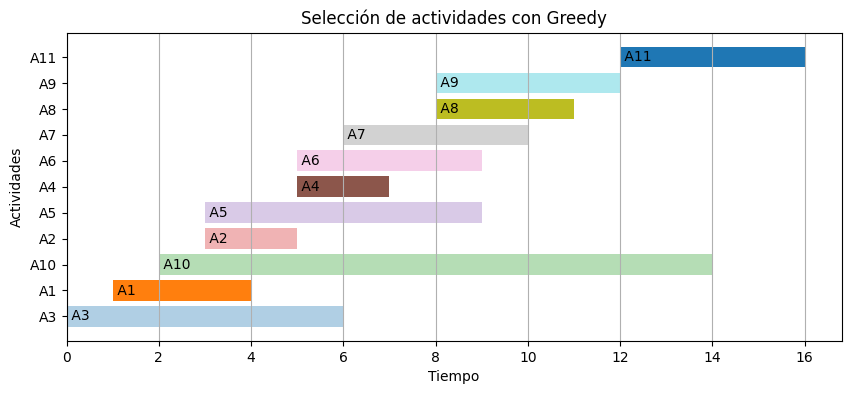

In [22]:
# Descomenta cuando implementes:
seleccion = seleccion_actividades_greedy(actividades_ejemplo)
graficar_actividades(actividades_ejemplo, seleccion, title="Selección de actividades con Greedy")


# 8. Experimento de rendimiento

Ahora mediremos el tiempo de ejecución del algoritmo greedy para diferentes tamaños de entrada.

El objetivo es observar cómo cambia el tiempo cuando aumenta el número de actividades `n`.


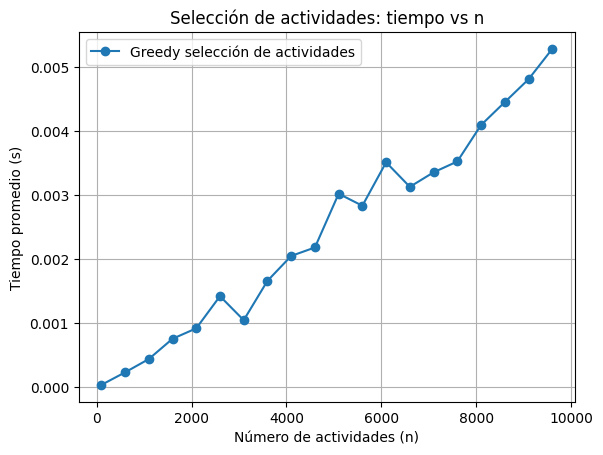

In [23]:
ns = list(range(100, 10001, 500))
tiempos_greedy = []

# Descomenta cuando implementes:
for n in ns:
     actividades = generar_actividades(n, max_time=100000, max_duration=1000, seed=n)
     t = medir_tiempo(seleccion_actividades_greedy, actividades, repeticiones=5)
     tiempos_greedy.append(t)

plt.figure()
plt.plot(ns, tiempos_greedy, marker="o", label="Greedy selección de actividades")
plt.xlabel("Número de actividades (n)")
plt.ylabel("Tiempo promedio (s)")
plt.title("Selección de actividades: tiempo vs n")
plt.grid(True)
plt.legend()
plt.show()


# 9. Curva de referencia asintótica

Para interpretar el crecimiento experimental, compararemos tu curva con una referencia teórica.

La solución greedy usualmente incluye una etapa de ordenamiento.  
Por eso, una referencia útil es:

\[
n \log n
\]

Esta comparación es cualitativa: la curva se escala para poder visualizar la tendencia.


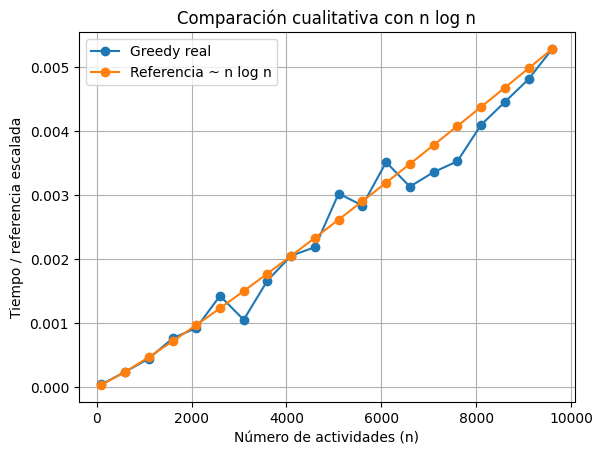

In [29]:
# Descomenta después de ejecutar el experimento anterior:

ref_nlogn = [n * math.log2(n) for n in ns]

scale = tiempos_greedy[-1] / ref_nlogn[-1]
ref_scaled = [x * scale for x in ref_nlogn]

plt.figure()
plt.plot(ns, tiempos_greedy, marker="o", label="Greedy real")
plt.plot(ns, ref_scaled, marker="o", label="Referencia ~ n log n")
plt.xlabel("Número de actividades (n)")
plt.ylabel("Tiempo / referencia escalada")
plt.title("Comparación cualitativa con n log n")
plt.grid(True)
plt.legend()
plt.show()


# 10. Comparación contra fuerza bruta

Esta sección muestra por qué necesitamos un enfoque eficiente.

La fuerza bruta revisa subconjuntos posibles, por lo que solo puede usarse para valores pequeños de `n`.

Ejecuta esta comparación con cuidado.


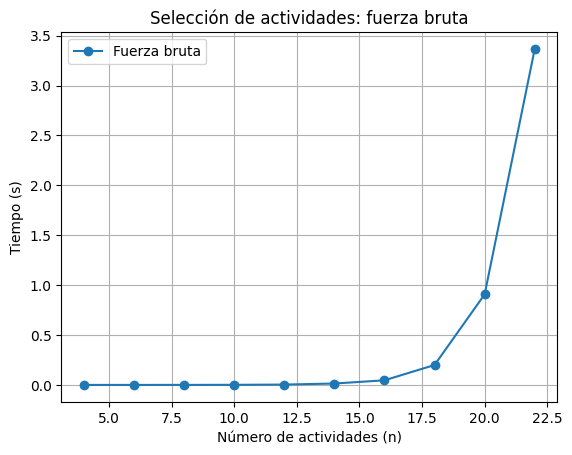

In [30]:
ns_bruta = list(range(4, 23, 2))
tiempos_bruta = []

# Descomenta si quieres comparar:
for n in ns_bruta:
    actividades = generar_actividades(n, max_time=50, max_duration=15, seed=n)
    t = medir_tiempo(seleccion_actividades_fuerza_bruta, actividades, repeticiones=1)
    tiempos_bruta.append(t)

plt.figure()
plt.plot(ns_bruta, tiempos_bruta, marker="o", label="Fuerza bruta")
plt.xlabel("Número de actividades (n)")
plt.ylabel("Tiempo (s)")
plt.title("Selección de actividades: fuerza bruta")
plt.grid(True)
plt.legend()
plt.show()


# 11. Preguntas para responder en el notebook

1. ¿Qué criterio greedy utilizaste para seleccionar actividades?
2. ¿Por qué ese criterio parece razonable?
3. ¿Tu solución coincidió con fuerza bruta en las pruebas pequeñas?
4. ¿Qué comportamiento observaste en la gráfica de rendimiento?
5. ¿Qué diferencia hay entre verificar experimentalmente y demostrar formalmente la solución?
6. ¿Por qué la demostración de la subestructura y de la decisión local debe hacerse fuera del notebook?

---

**1. ¿Qué criterio greedy utilizaste para seleccionar actividades?**

El criterio utilizado fue el Tiempo de Finalización más Temprano. El algoritmo ordena todas las actividades de menor a mayor según su tiempo de término ($f_i$) y selecciona siempre la primera actividad disponible que no se traslape con la última seleccionada

**2. ¿Por qué ese criterio parece razonable?**

Si eliges la actividad que termina más pronto, estás dejando el mayor tiempo posible libre para el resto del día. Esto minimiza el desperdicio de tiempo inicial y maximiza las oportunidades de encajar más tareas en el horario

**3. ¿Tu solución coincidió con fuerza bruta en las pruebas pequeñas?**

Sí. el algoritmo Greedy encontró la misma cantidad de actividades que la Fuerza Bruta

**4. ¿Qué comportamiento observaste en la gráfica de rendimiento?**

Mientras que el tiempo del algoritmo Greedy mostró un crecimiento casi plano (lineal-logarítmico, $O(n \log n)$), procesando hasta 10,000 actividades en milisegundos. Fuerza Bruta: Mostró un crecimiento exponencial ($O(2^n)$), donde el tiempo de ejecución se disparó verticalmente al superar las 20 actividades, volviéndose ineficiente rápidamente

**5. ¿Qué diferencia hay entre verificar experimentalmente y demostrar formalmente la solución?**

La **Verificación experimental** comprueba que el algoritmo funciona correctamente para un conjunto específico y finito de datos, pero no garantiza que no exista un caso extraño donde falle, y la **Demostración formal** utiliza lógica matemática para asegurar que el algoritmo es correcto para cualquier entrada posible sin importar su tamaño o configuración

**6. ¿Por qué la demostración de la subestructura y de la decisión local debe hacerse fuera del notebook?**

Un algoritmo greedy no se valida únicamente por pruebas experimentales
, el código por sí solo no puede generar un análisis deductivo, ya que el código solo ejecuta instrucciones, no construye pruebas de validez universal